In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [3]:
data = pd.read_csv("alzheimers_disease_data.csv")
print(data.head())

   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       4751   73       0          0               2  22.927749        0   
1       4752   89       0          0               0  26.827681        0   
2       4753   73       0          3               1  17.795882        0   
3       4754   74       1          0               1  33.800817        1   
4       4755   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  ...  MemoryComplaints  \
0           13.297218          6.327112     1.347214  ...                 0   
1            4.542524          7.619885     0.518767  ...                 0   
2           19.555085          7.844988     1.826335  ...                 0   
3           12.209266          8.428001     7.435604  ...                 0   
4           18.454356          6.310461     0.795498  ...                 0   

   BehavioralProblems       ADL  Confusion  Disorientation  \
0     

In [4]:
X = data.drop(columns=["PatientID", "DoctorInCharge", "Diagnosis"])
y = data["Diagnosis"]

print("Input Data:")
print(X.head())
print("Output Data:")
print(y.head())

Input Data:
   Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0   73       0          0               2  22.927749        0   
1   89       0          0               0  26.827681        0   
2   73       0          3               1  17.795882        0   
3   74       1          0               1  33.800817        1   
4   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  SleepQuality  ...  \
0           13.297218          6.327112     1.347214      9.025679  ...   
1            4.542524          7.619885     0.518767      7.151293  ...   
2           19.555085          7.844988     1.826335      9.673574  ...   
3           12.209266          8.428001     7.435604      8.392554  ...   
4           18.454356          6.310461     0.795498      5.597238  ...   

        MMSE  FunctionalAssessment  MemoryComplaints  BehavioralProblems  \
0  21.463532              6.518877                 0                  

In [5]:
model = LogisticRegression(max_iter=1000)
model.fit(X, y)
print("Logistic Regression Score:", model.score(X, y))

model2 = RandomForestClassifier(n_estimators=100)
model2.fit(X, y)
print("Random Forest Score:", model2.score(X, y))

c:\Users\mchin\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Score: 0.8380642159143787
Random Forest Score: 1.0


In [6]:
pickle.dump(model2, open("alzheimers_rf.pkl", "wb"))
print("Model saved successfully!")

Model saved successfully!


In [7]:
model2 = pickle.load(open("alzheimers_rf.pkl", "rb"))
print("Model loaded successfully!")

Model loaded successfully!


In [8]:
test_data = np.array([[73,0,0,2,22.92,0,13.29,6.32,1.34,9.02,0,0,1,1,0,0,142,72,
                       242.36,56.15,33.68,162.18,21.46,6.51,0,0,1.72,0,0,0,1,0]])

prediction = model2.predict(test_data)

if prediction[0] == 1:
    print("Patient may have Alzheimer's Disease")
else:
    print("Patient does NOT have Alzheimer's Disease")

Patient does NOT have Alzheimer's Disease


c:\Users\mchin\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [9]:
risk_proba = model2.predict_proba(test_data)[0][1] * 100
print(f"Risk Percentage: {risk_proba:.2f}%")

if risk_proba < 30:
    risk_level = "Low Risk"
elif 30 <= risk_proba < 70:
    risk_level = "Moderate Risk"
else:
    risk_level = "High Risk"

print("Risk Level:", risk_level)

Risk Percentage: 1.00%
Risk Level: Low Risk


c:\Users\mchin\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [10]:
if prediction[0] == 1 or risk_proba > 50:
    precautions = [
        "Maintain a balanced diet rich in omega-3 and antioxidants.",
        "Engage in regular physical exercise and cognitive activities.",
        "Ensure consistent sleep patterns.",
        "Manage cardiovascular risk factors (e.g., blood pressure, diabetes).",
        "Consult a neurologist for further assessment and treatment options."
    ]
else:
    precautions = [
        "Maintain a healthy lifestyle and diet.",
        "Engage in routine brain-stimulating activities.",
        "Schedule regular health check-ups."
    ]

print("\nPrecautions / Recommendations:")
for p in precautions:
    print("-", p)


Precautions / Recommendations:
- Maintain a healthy lifestyle and diet.
- Engage in routine brain-stimulating activities.
- Schedule regular health check-ups.


In [11]:
from fpdf import FPDF

pdf = FPDF()
pdf.add_page()
pdf.set_font("Arial", "B", 16)
pdf.cell(200, 10, txt="Alzheimer's Disease Prediction Report", ln=True, align="C")
pdf.set_font("Arial", size=12)
pdf.ln(10)
pdf.cell(200, 10, txt=f"Prediction: {'Positive (Disease Detected)' if prediction[0] == 1 else 'Negative (No Disease)'}", ln=True)
pdf.cell(200, 10, txt=f"Risk Percentage: {risk_proba:.2f}%", ln=True)
pdf.cell(200, 10, txt=f"Risk Level: {risk_level}", ln=True)
pdf.ln(5)
pdf.cell(200, 10, txt="Recommended Precautions:", ln=True)
pdf.set_font("Arial", size=11)
for p in precautions:
    pdf.multi_cell(0, 10, f"- {p}")

report_path = "patient_report.pdf"
pdf.output(report_path)
print(f"Report saved at: {report_path}")

Report saved at: patient_report.pdf


In [14]:
print("Enter Patient Details:")

age = float(input("Age: "))
gender = float(input("Gender (0=Male, 1=Female): "))
ethnicity = float(input("Ethnicity (0/1/2/3): "))
education = float(input("Education Level (0/1/2/3): "))
bmi = float(input("BMI: "))
smoking = float(input("Smoking (0=No, 1=Yes): "))
alcohol = float(input("Alcohol Consumption: "))
physical = float(input("Physical Activity (hours/week): "))
diet = float(input("Diet Quality (0-10): "))
sleep = float(input("Sleep Quality (0-10): "))
family_history = float(input("Family History of Alzheimer's (0=No, 1=Yes): "))
cardiovascular = float(input("Cardiovascular Disease (0=No, 1=Yes): "))
diabetes = float(input("Diabetes (0=No, 1=Yes): "))
depression = float(input("Depression (0=No, 1=Yes): "))
head_injury = float(input("Head Injury (0=No, 1=Yes): "))
hypertension = float(input("Hypertension (0=No, 1=Yes): "))
systolic_bp = float(input("Systolic Blood Pressure: "))
diastolic_bp = float(input("Diastolic Blood Pressure: "))
cholesterol_total = float(input("Total Cholesterol: "))
cholesterol_ldl = float(input("Cholesterol LDL: "))
cholesterol_hdl = float(input("Cholesterol HDL: "))
cholesterol_trig = float(input("Cholesterol Triglycerides: "))
mmse = float(input("MMSE Score (0-30): "))
functional = float(input("Functional Assessment (0-10): "))
memory = float(input("Memory Complaints (0=No, 1=Yes): "))
behavioral = float(input("Behavioral Problems (0=No, 1=Yes): "))
adl = float(input("ADL Score (0-10): "))
confusion = float(input("Confusion (0=No, 1=Yes): "))
disorientation = float(input("Disorientation (0=No, 1=Yes): "))
personality = float(input("Personality Changes (0=No, 1=Yes): "))
difficulty_tasks = float(input("Difficulty Completing Tasks (0=No, 1=Yes): "))
forgetfulness = float(input("Forgetfulness (0=No, 1=Yes): "))

test_data = np.array([[age, gender, ethnicity, education, bmi, smoking, alcohol,
                       physical, diet, sleep, family_history, cardiovascular,
                       diabetes, depression, head_injury, hypertension, systolic_bp,
                       diastolic_bp, cholesterol_total, cholesterol_ldl, cholesterol_hdl,
                       cholesterol_trig, mmse, functional, memory, behavioral, adl,
                       confusion, disorientation, personality, difficulty_tasks, forgetfulness]])

prediction = model2.predict(test_data)

if prediction[0] == 1:
    print("\nPatient may have Alzheimer's Disease")
else:
    print("\nPatient does NOT have Alzheimer's Disease")


Enter Patient Details:

Patient may have Alzheimer's Disease


c:\Users\mchin\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


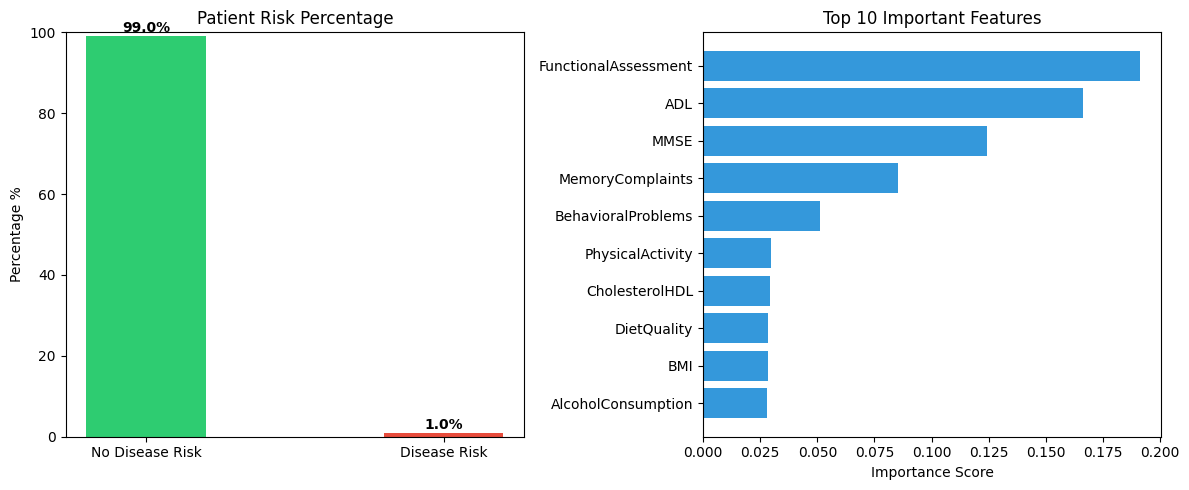

Chart saved!


In [15]:
import matplotlib.pyplot as plt

# Graph 1 — Risk Gauge Bar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left chart — Risk percentage bar
categories = ["No Disease Risk", "Disease Risk"]
values = [100 - risk_proba, risk_proba]
colors = ["#2ecc71", "#e74c3c"]

axes[0].bar(categories, values, color=colors, width=0.4)
axes[0].set_title("Patient Risk Percentage")
axes[0].set_ylabel("Percentage %")
axes[0].set_ylim(0, 100)
for i, v in enumerate(values):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

# Right chart — Feature importance
feature_names = X.columns.tolist()
importances = model2.feature_importances_
top_indices = importances.argsort()[-10:]

axes[1].barh([feature_names[i] for i in top_indices],
             [importances[i] for i in top_indices],
             color="#3498db")
axes[1].set_title("Top 10 Important Features")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("patient_risk_chart.png")
plt.show()
print("Chart saved!")